In [1]:
options(warn = -1)
suppressMessages(require(Seurat))
suppressMessages(require(ggplot2))
suppressMessages(require(dplyr))
suppressMessages(require(reticulate))
suppressMessages(require(stringr))
suppressMessages(require(ggpubr))
suppressMessages(require(tidydr))
suppressMessages(require(CellTrek))
suppressMessages(require(CARD))
suppressMessages(require(monocle))
suppressMessages(require(viridis))
devtools::load_all('../Cell2Spatial/')

ℹ Loading Cell2Spatial


In [2]:
source('modules/globalParams.R')
source('modules/utils.R')
source('modules/vis.R')
source('modules/reformatProjRes.R')

In [284]:
out.figs.dir <- '../2.results/Mouse.kidney.1/figs'
out.data.dir <- '../2.results/Mouse.kidney.1/data'

In [285]:
dir.create(out.figs.dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out.data.dir, showWarnings = FALSE, recursive = TRUE)

In [286]:
MTH_COLOR <- c(
    'Reference'    = 'grey',
    'Cell2Spatial' = '#F7B263',
    'CytoSPACE' = '#D6AA8E',
    'CellTrek' = '#99C0CC',
    'Tangram' = 'lightgreen',
    'Seurat' = '#CC00FF'
)

### Loading kidney ST and SC datasets 

In [9]:
brain.st <- readRDS('../0.data/Mouse.kidney/Kindney_SP.RDS')

In [10]:
#brain.st <- readRDS('../0.data/Mouse.kidney/xx.data/Mouse.Kidney_SP.RDS')

In [11]:
brain.st

An object of class Seurat 
32285 features across 1438 samples within 1 assay 
Active assay: Spatial (32285 features, 0 variable features)
 2 layers present: counts, data
 1 image present: slice1

In [288]:
brain.sc <- readRDS('../0.data/Mouse.kidney/Kindney_SC2.RDS')

In [289]:
levels(brain.sc)

[1] "Macro"    "Vascular" "ProxTub"  "Prin"     "DistTub"  "TLLH"    
 [7] "T"        "VSMC"     "B"        "Inter"    "NK"       "UNKNOW"  
[13] "RenaCorp" "Fb"

In [290]:
brain.st <- brain.st %>% SCTransform(., verbose = FALSE, assay = 'Spatial') %>%
    RunPCA(verbose = FALSE) %>%
    RunUMAP(dims = 1 : 30, verbose = FALSE) %>%
    FindNeighbors(., dims = 1:30, verbose = FALSE, res = 0.5) %>%
    FindClusters(., verbose = FALSE)

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’



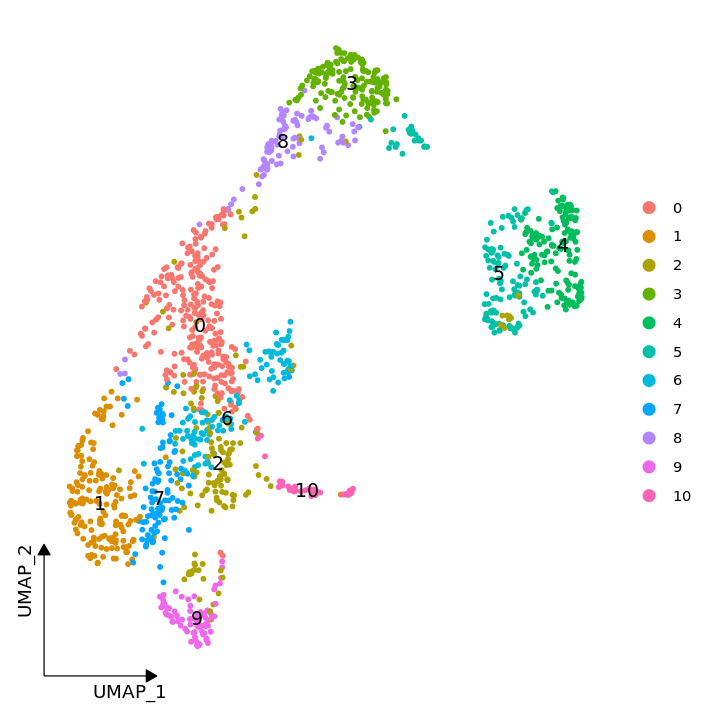

In [291]:
options(repr.plot.width = 6, repr.plot.height = 6)
DimPlot(brain.st, reduction = "umap", label = TRUE) + theme_dr(xlength = 0.2, ylength = 0.2, arrow = grid::arrow(length = unit(0.1, "inches"), ends = 'last', type = "closed")) + theme(panel.grid = element_blank())
ggsave(file.path(out.figs.dir, 'Kindney.ST.cluster.UMAP.dimplot.pdf'), width = 6, height = 6)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


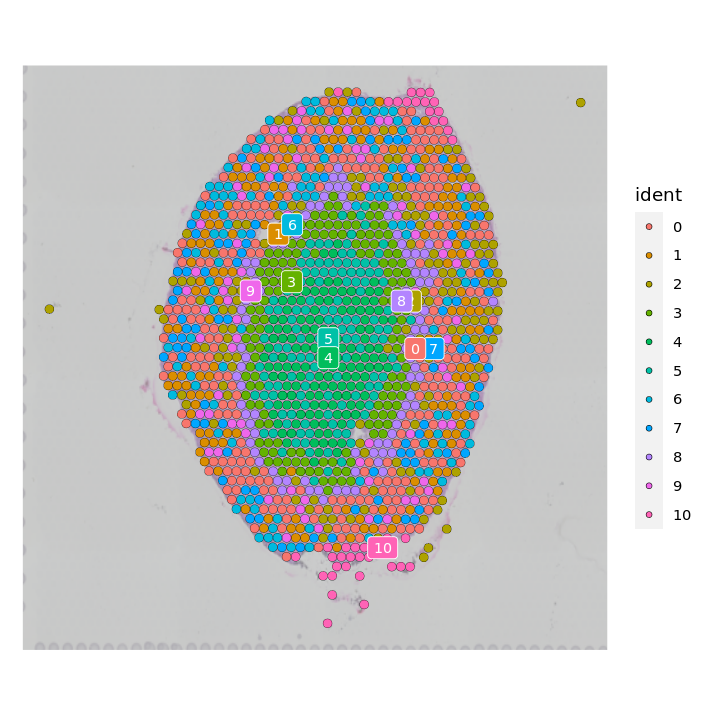

In [292]:
options(repr.plot.width = 6, repr.plot.height = 6)
SpatialDimPlot(brain.st, label = TRUE, label.size = 3, image.alpha = 0.5)
ggsave(file.path(out.figs.dir, 'brain.ST.cluster.UMAP.spatial.pdf'), width = 6, height = 6)

In [293]:
f.ctypes <- levels(brain.st)
gps <- lapply(f.ctypes, function(ct) {
    h.cells <- subset(brain.st, idents = ct) %>% Cells
    SpatialPlot(brain.st, cells.highlight = h.cells) + NoLegend() + ggtitle(ct) 
})

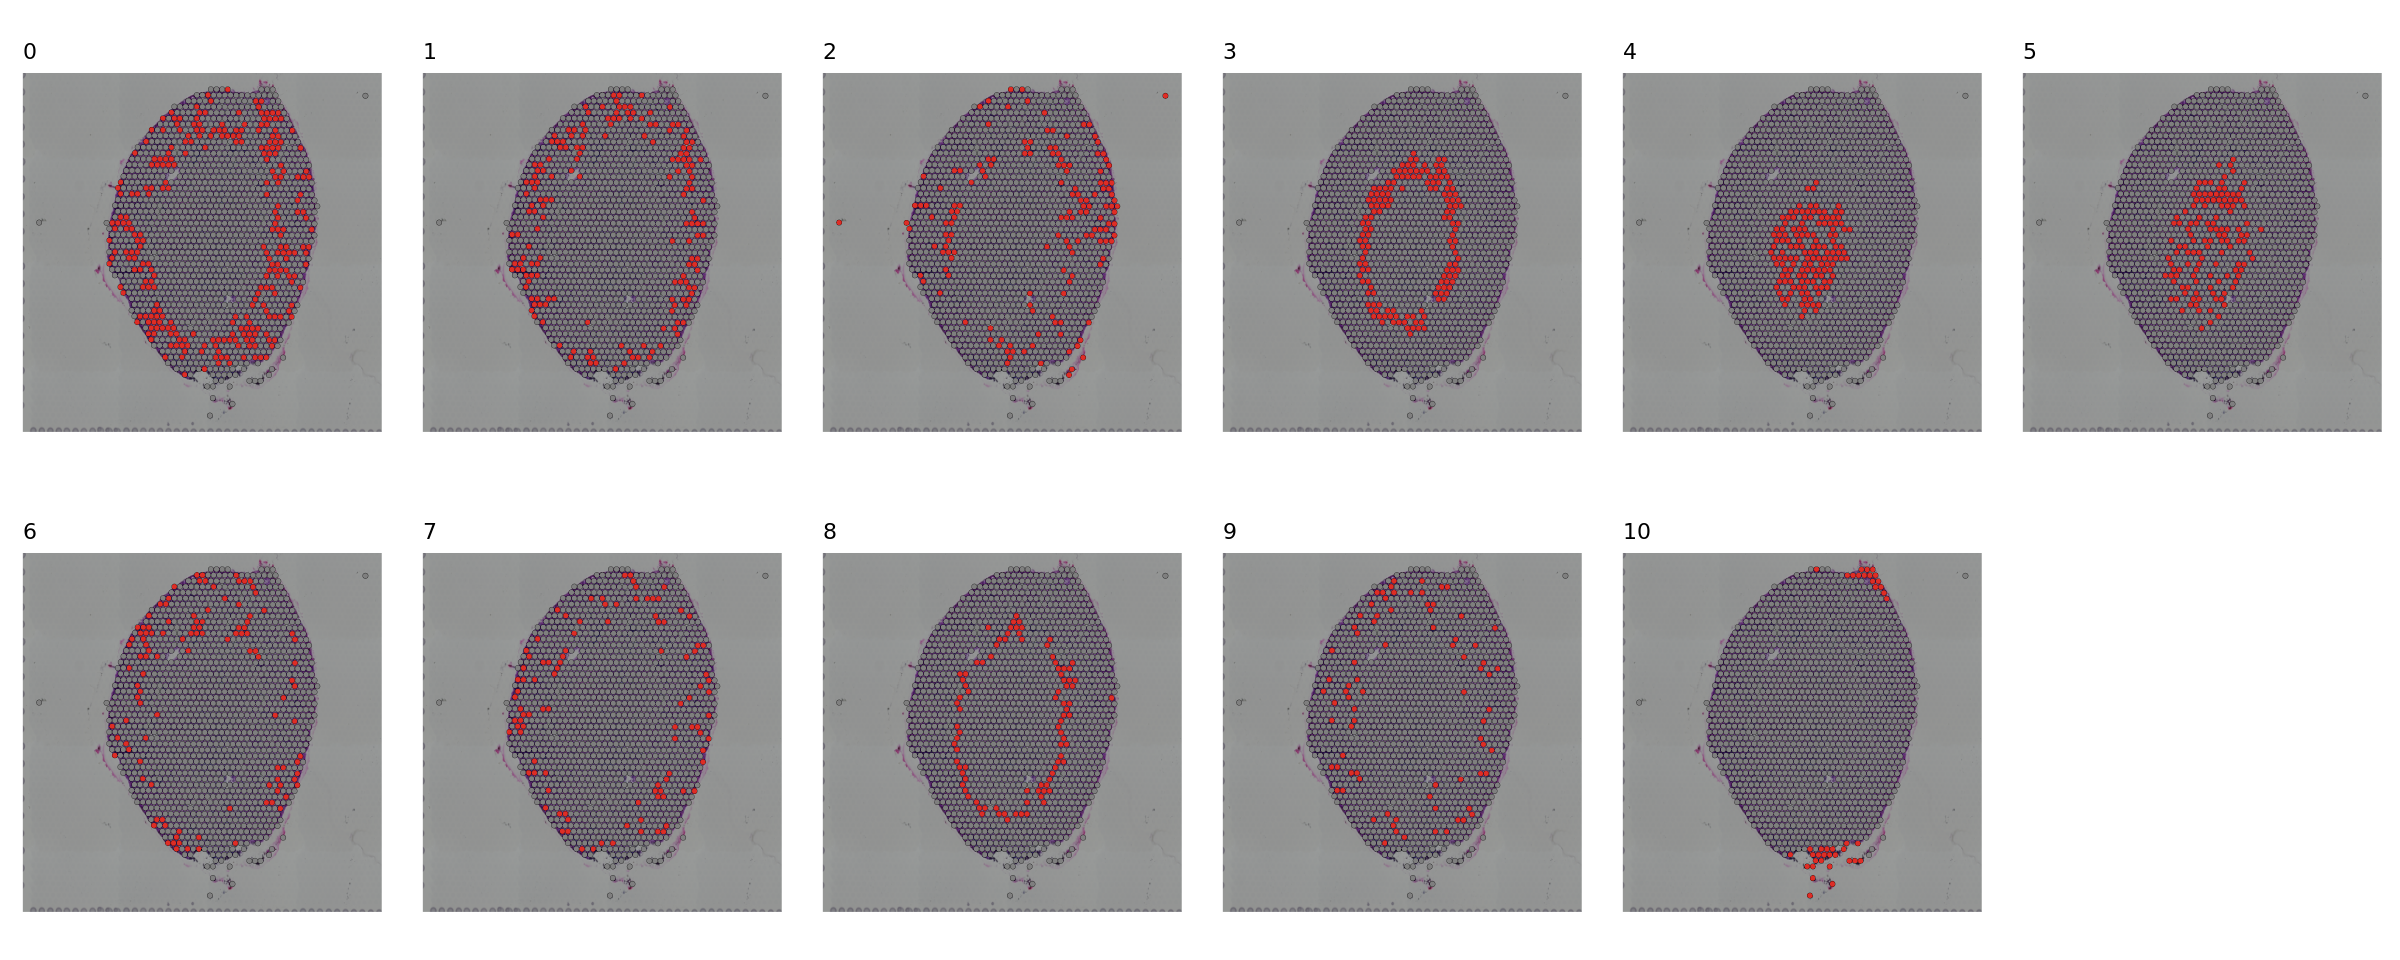

In [294]:
options(repr.plot.width = 20, repr.plot.height = 8)
ggarrange(plotlist = gps, nrow = 2, ncol = 6)

ggsave(file.path(out.figs.dir, 'brain.ST.UMAP.split.spatial.pdf'), width = 20, height = 8)

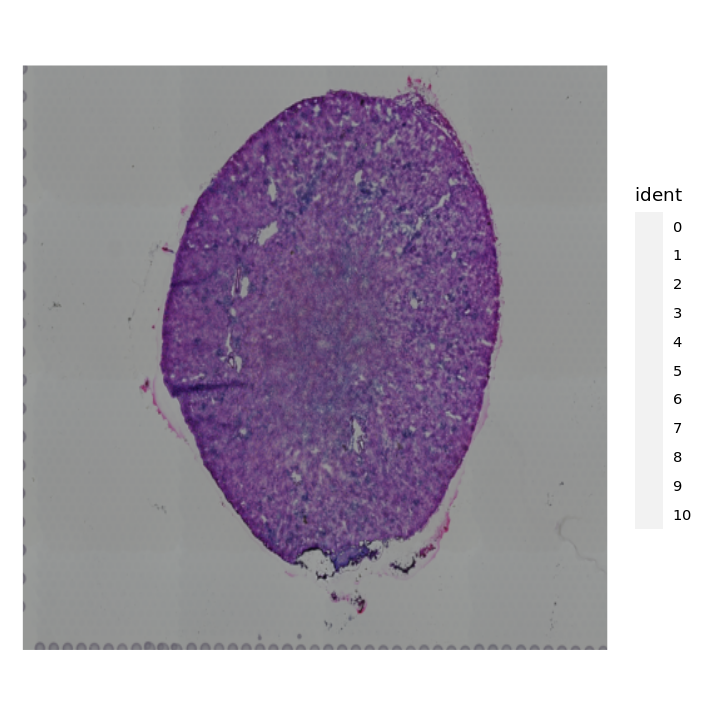

In [295]:
options(repr.plot.width = 6, repr.plot.height = 6)
SpatialDimPlot(brain.st, label = FALSE, label.size = 3,, alpha = 0)
ggsave(file.path(out.figs.dir, 'brain.ST.Image.spatial.pdf'), width = 6, height = 6)

In [296]:
brain.sc@meta.data %>% head

,orig.ident,nCount_RNA,nFeature_RNA,nGene,nUMI,replicate,percent.mito,sex,res.1,Lineages,Ontology_ID,mainCtype
,<fct>,<dbl>,<int>,<int>,<dbl>,<fct>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>
Z1_F_F1_AAACCTGAGGGCTTCC,Z1,2379.456,1633,1633,4752,F1,0.22790404,F,10,Nephron epithelium,5,ProxTub
Z1_F_F1_AAACCTGCAGGACGTA,Z1,3110.128,2136,2136,4624,F1,0.02941176,F,2,Vasculature,NA,Vascular
Z1_F_F1_AAACCTGGTATTCGTG,Z1,2421.857,1204,1204,2126,F1,0.02022578,F,2,Vasculature,NA,Vascular
Z1_F_F1_AAACCTGTCAAACCAC,Z1,2162.187,1012,1013,1742,F1,0.01148765,F,2,Vasculature,NA,Vascular
Z1_F_F1_AAACGGGAGGCGACAT,Z1,2754.327,2079,2079,6079,F1,0.03750617,F,12,Nephron epithelium,18,DistTub
Z1_F_F1_AAACGGGCACAGATTC,Z1,2933.118,1824,1824,3693,F1,0.01678852,F,11,Vasculature,NA,Vascular


In [297]:
Idents(brain.sc) <- brain.sc$mainCtype

In [298]:
brain.sc <- SCTransform(brain.sc, ncells = 3000, verbose = FALSE) %>%
    RunPCA(verbose = FALSE) %>%
    RunUMAP(dims = 1 : 30, verbose = FALSE)

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by ‘spam’



In [299]:
brain.sc@meta.data %>% head

,orig.ident,nCount_RNA,nFeature_RNA,nGene,nUMI,replicate,percent.mito,sex,res.1,Lineages,Ontology_ID,mainCtype,nCount_SCT,nFeature_SCT
,<fct>,<dbl>,<int>,<int>,<dbl>,<fct>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<int>
Z1_F_F1_AAACCTGAGGGCTTCC,Z1,2379.456,1633,1633,4752,F1,0.22790404,F,10,Nephron epithelium,5,ProxTub,2340,1633
Z1_F_F1_AAACCTGCAGGACGTA,Z1,3110.128,2136,2136,4624,F1,0.02941176,F,2,Vasculature,NA,Vascular,2597,2136
Z1_F_F1_AAACCTGGTATTCGTG,Z1,2421.857,1204,1204,2126,F1,0.02022578,F,2,Vasculature,NA,Vascular,2599,1204
Z1_F_F1_AAACCTGTCAAACCAC,Z1,2162.187,1012,1013,1742,F1,0.01148765,F,2,Vasculature,NA,Vascular,2315,1012
Z1_F_F1_AAACGGGAGGCGACAT,Z1,2754.327,2079,2079,6079,F1,0.03750617,F,12,Nephron epithelium,18,DistTub,2616,2079
Z1_F_F1_AAACGGGCACAGATTC,Z1,2933.118,1824,1824,3693,F1,0.01678852,F,11,Vasculature,NA,Vascular,2523,1824


In [300]:
set.seed(2023063) 
cell.colors <- randomcoloR::distinctColorPalette(length(unique(brain.sc$mainCtype )))  %>% `names<-`(unique(brain.sc$mainCtype))

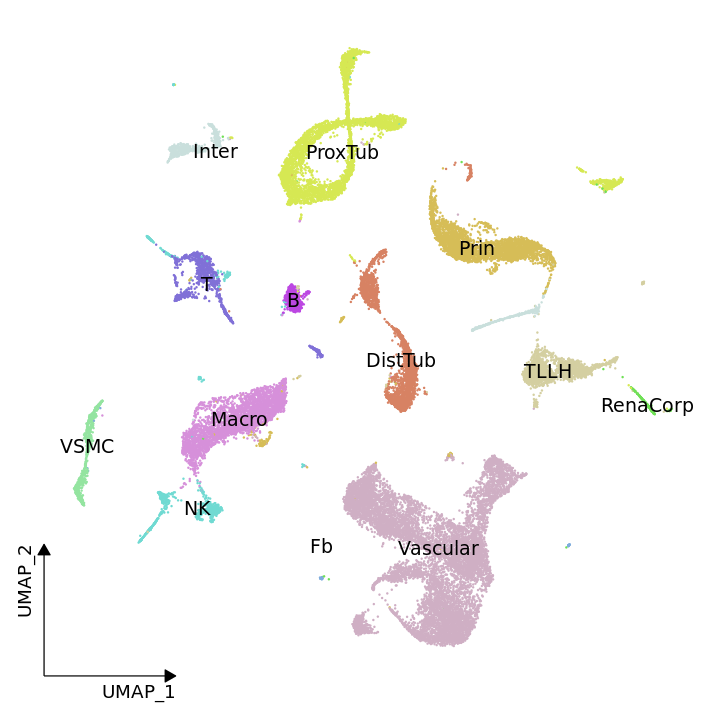

In [475]:
options(repr.plot.width = 6, repr.plot.height = 6)
brain.sc.sub <- subset(brain.sc, mainCtype == 'UNKNOW', invert = TRUE)
DimPlot(brain.sc.sub, label = TRUE, cols = cell.colors) + theme_dr(xlength = 0.2, ylength = 0.2, arrow = grid::arrow(length = unit(0.1, "inches"), ends = 'last', type = "closed")) + theme(panel.grid = element_blank()) + NoLegend()
ggsave(file.path(out.figs.dir, 'brain.SC.cluster.UMAP.dimplot.pdf'), width = 6, height = 6)

In [574]:
dim(brain.st)

[1] 17097  1438

In [573]:
unique(brain.sc$mainCtype) %>% length

[1] 14

In [302]:
#markers <- FindAllMarkers(brain.st, only.pos = TRUE, logfc.threshold = 0.25, min.pct = 0.25, assay = 'SCT')

In [303]:
#openxlsx::write.xlsx(markers, file = file.path(out.data.dir, 'Mouse.Kidney.ST.markers.xlsx'))

In [304]:
#top20.markers <- markers %>% group_by(cluster) %>% top_n(n = 20, wt = avg_log2FC)

In [305]:
#saveRDS(brain.sc, file = file.path(out.data.dir, 'brain.sc.RDS'))
#saveRDS(brain.st, file = file.path(out.data.dir, 'brain.st.RDS'))

### Pseudo-time analysis
- for ProxTub

In [478]:
coul <- colorRampPalette(RColorBrewer::brewer.pal(8, "YlGn"))(25)

In [479]:
proxtub.obj <- subset(brain.sc, mainCtype == 'ProxTub')

In [480]:
proxtub.obj <- createMonocleObject(proxtub.obj)

In [497]:
proxtub.cds <- monocle2Analysis(proxtub.obj, cut.expr = 0.2)

Removing 259 outliers



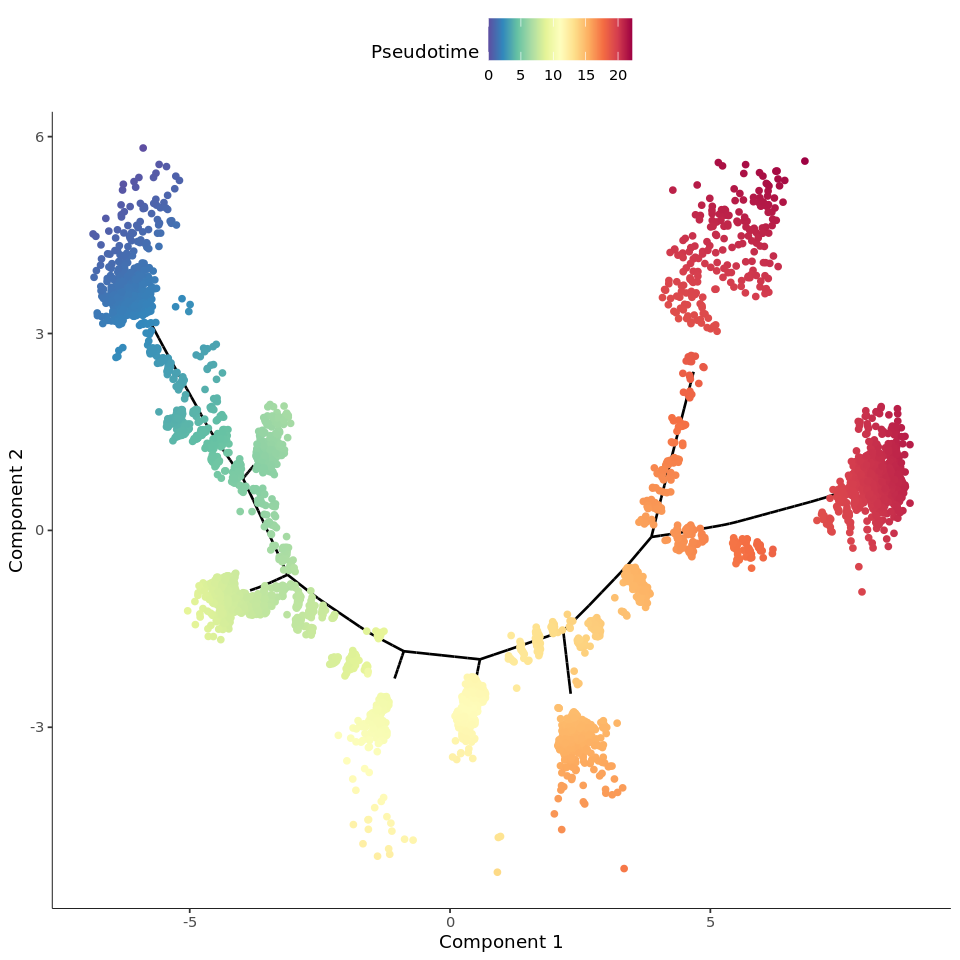

In [528]:
plot_cell_trajectory(proxtub.cds, color_by = "Pseudotime", show_branch_points = FALSE) + scale_color_gradientn(colours=SpatialColors(n=100))

ggsave(file.path(out.figs.dir, 'proxtub.pseudo.ddtree.pdf'), width = 6, height = 6)

- for DistTub

In [483]:
disttub.obj <- subset(brain.sc, mainCtype == 'DistTub')

In [484]:
disttub.obj <- createMonocleObject(disttub.obj)

In [485]:
disttub.cds <- monocle2Analysis(disttub.obj, cut.expr = 0.5)

Removing 276 outliers



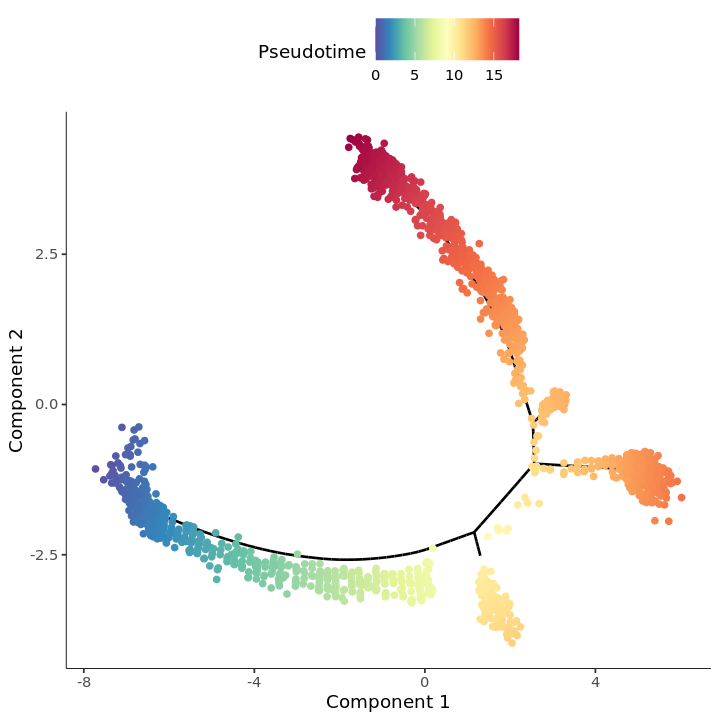

In [486]:
plot_cell_trajectory(disttub.cds, color_by = "Pseudotime", show_branch_points = FALSE) + scale_color_gradientn(colours=SpatialColors(n=100))

ggsave(file.path(out.figs.dir, 'disttub.pseudo.ddtree.pdf'), width = 6, height = 6)

### Showing the projection performance for Cell2Spatial

In [5]:
cell2spatial <- readRDS('../2.results/Mouse.kidney.1//data//kidney.2.cell2spatial.RDS')$obj

In [6]:
cell2spatial

An object of class Seurat 
15354 features across 14380 samples within 1 assay 
Active assay: Spatial (15354 features, 0 variable features)
 2 layers present: counts, data
 1 image present: slice1

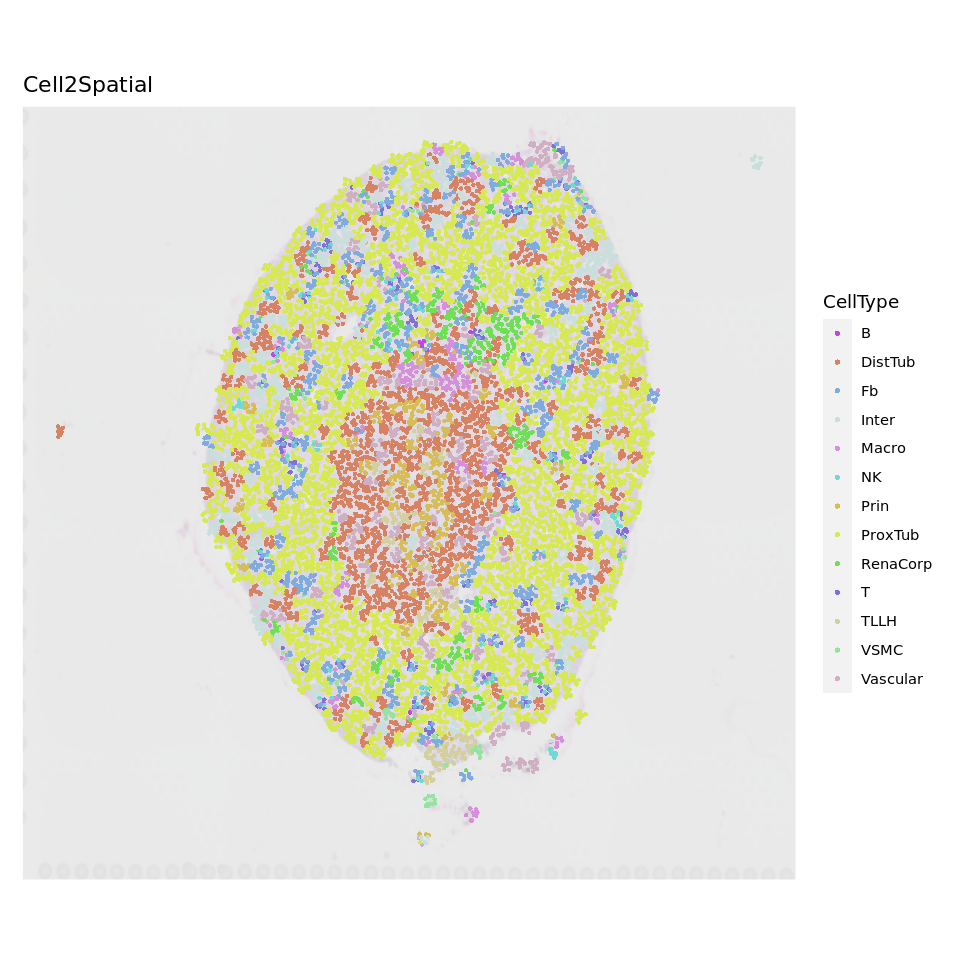

In [569]:
options(repr.plot.width = 8, repr.plot.height = 8)
SpatialPlot(cell2spatial, group.by = 'CellType', pt.size = 0.6, image.alpha = 0.5, stroke = NA, cols = cell.colors) + ggtitle('Cell2Spatial')
ggsave(file.path(out.figs.dir, 'cell2spatial.entire.UMAP.pdf'), width = 10, height = 4)

In [257]:
f.ctypes <- cell2spatial$CellType %>% unique
gps <- lapply(f.ctypes, function(ct) {
    h.cells <- subset(cell2spatial, CellType == ct) %>% Cells
    obj.sub <- cell2spatial[, h.cells]
    SpatialDimPlot(obj.sub, image.alpha = 0.5, group.by = 'CellType',  pt.size.factor = 1, crop = FALSE, stroke = 0) + ggtitle(ct) + NoLegend()  
})

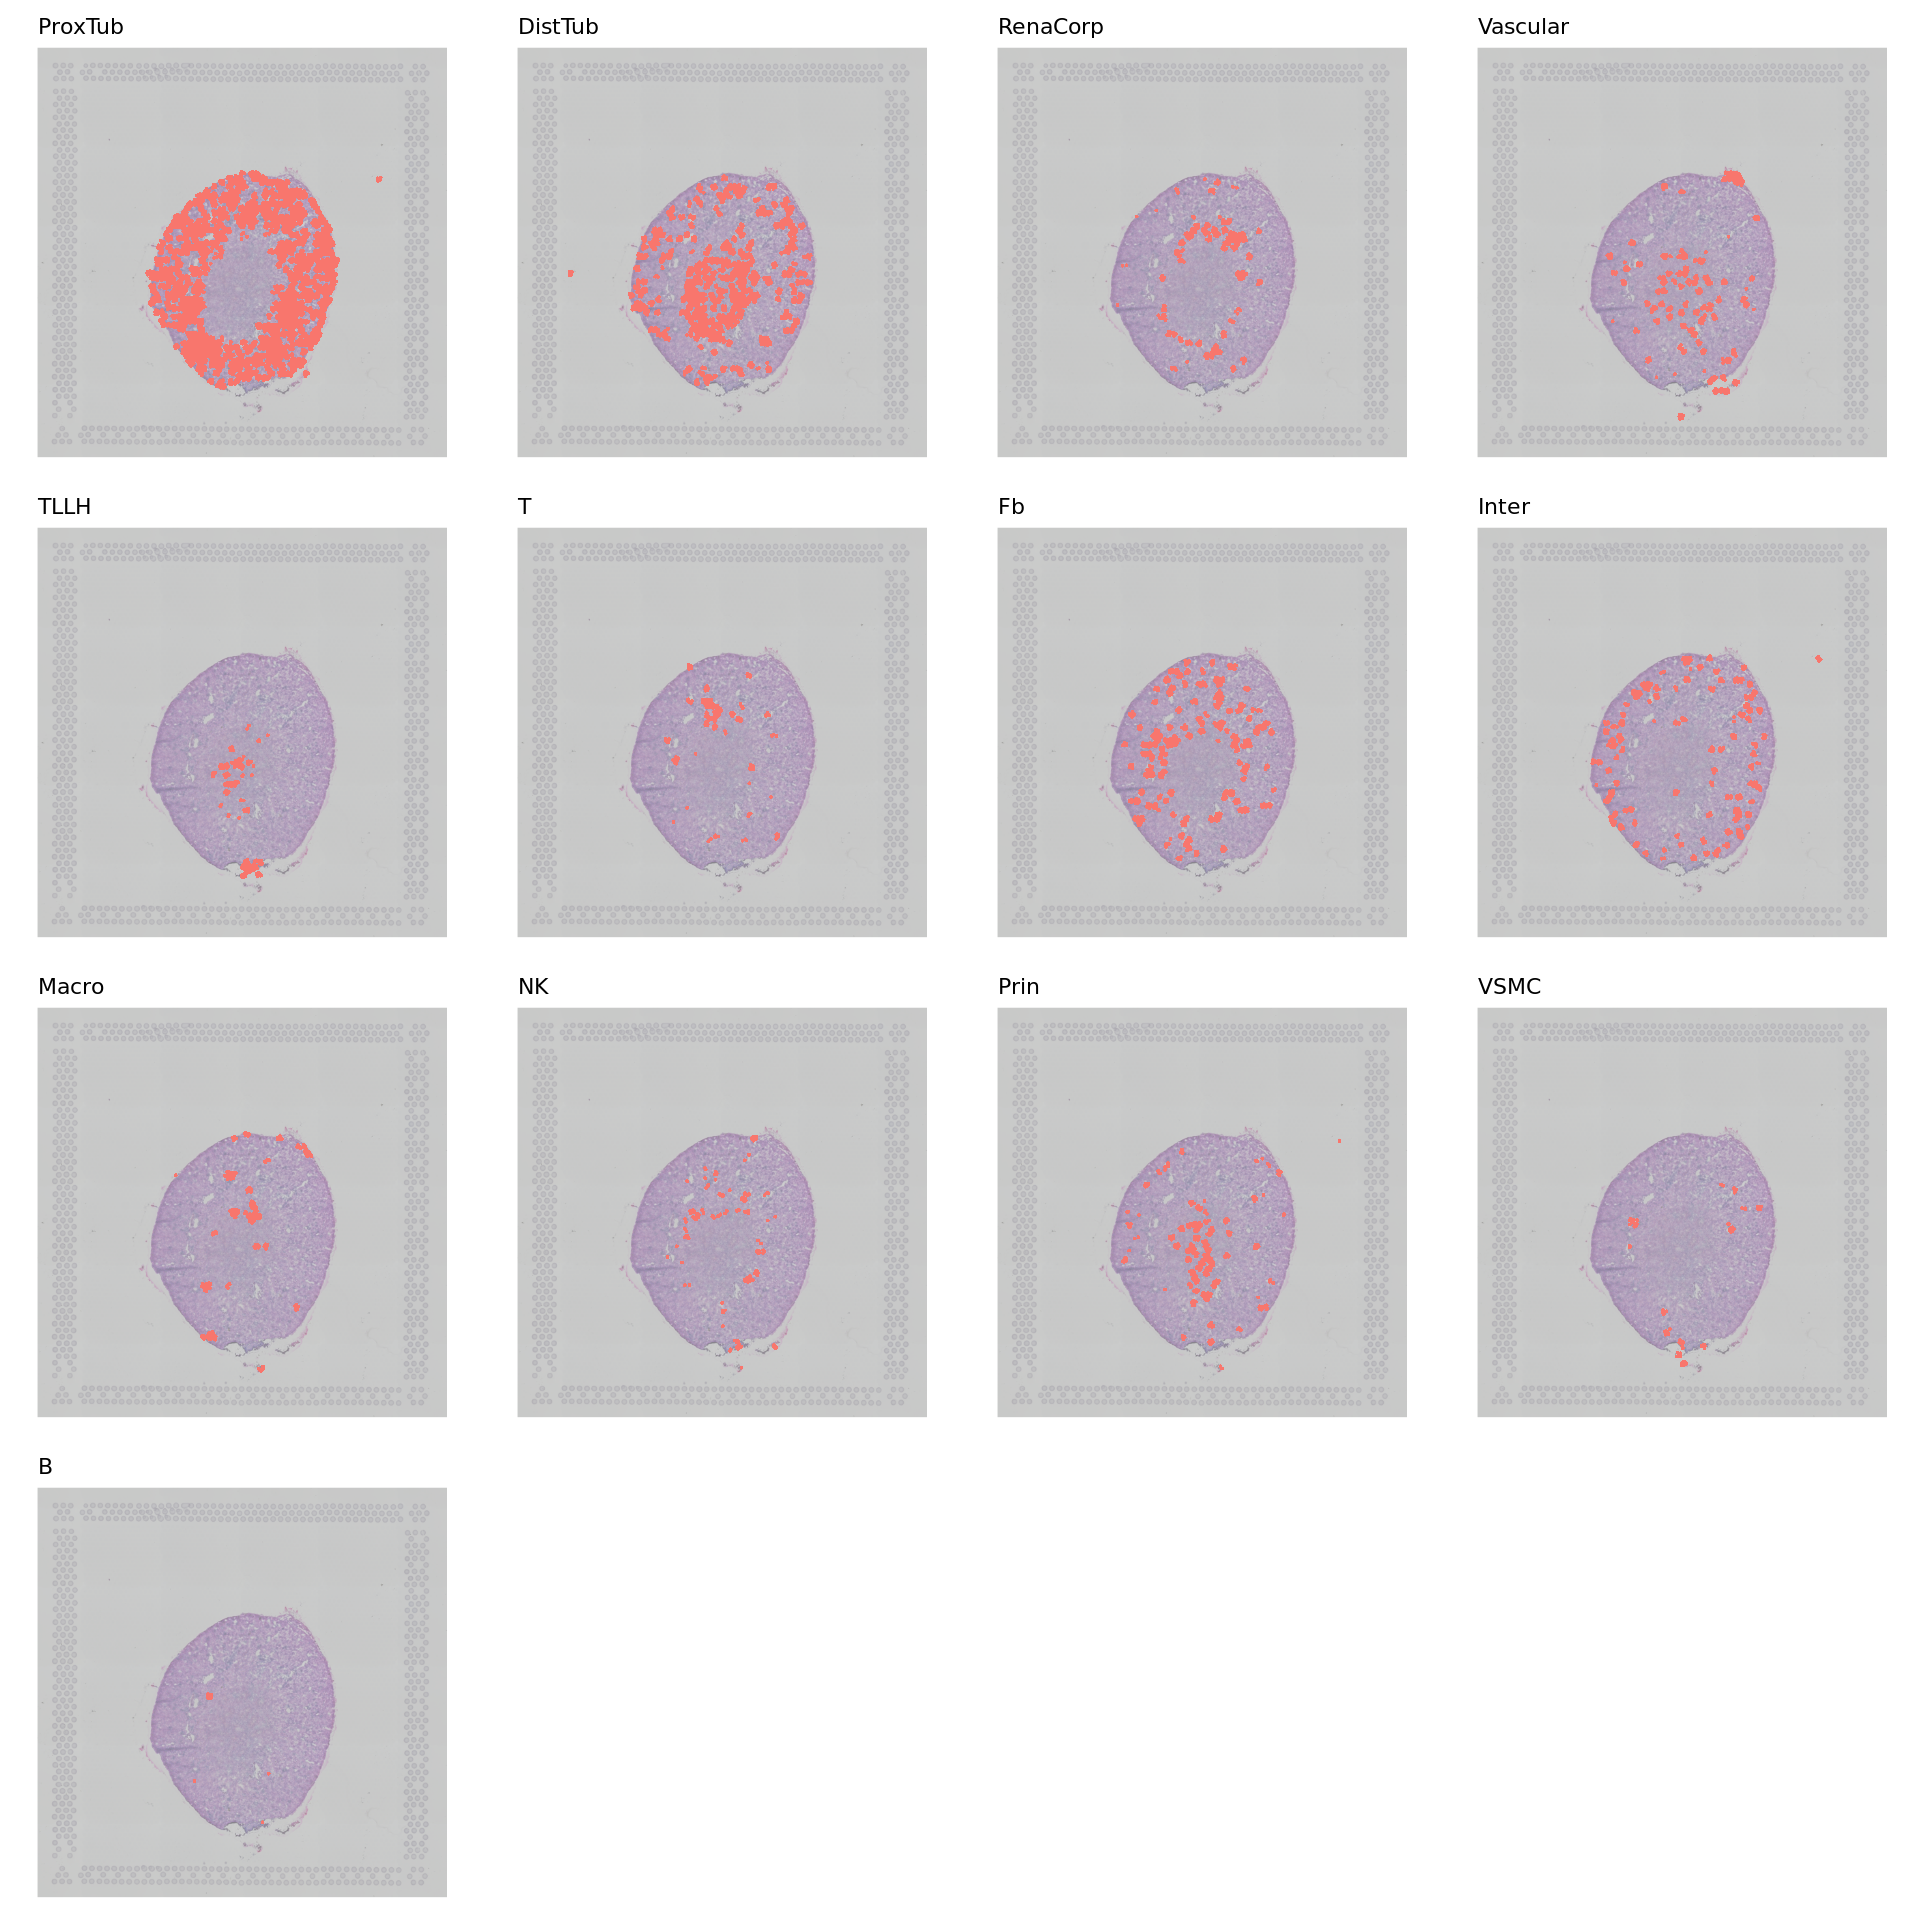

In [258]:
options(repr.plot.width = 16, repr.plot.height = 16)
ggarrange(plotlist = gps, nrow = 4, ncol = 4)
ggsave(file.path(out.figs.dir, 'cell2spatial.split.UMAP.pdf'), width = 16, height = 16)

#### Mapping trajectory results to cells

In [522]:
meta.data <- pData(proxtub.cds@phenoData)
head(meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,nGene,nUMI,replicate,percent.mito,sex,res.1,Lineages,Ontology_ID,mainCtype,nCount_SCT,nFeature_SCT,Size_Factor,num_genes_expressed,Pseudotime,State
,<fct>,<dbl>,<int>,<int>,<dbl>,<fct>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<fct>
Z1_F_F1_AAACCTGAGGGCTTCC,Z1,2379.456,1633,1633,4752,F1,0.22790404,F,10,Nephron epithelium,5,ProxTub,2340,1633,0.8578425,1633,16.307933,10
Z1_F_F1_AAAGATGCAGCCTATA,Z1,2555.799,2121,2122,8175,F1,0.20271593,F,10,Nephron epithelium,5,ProxTub,2796,2121,1.0401247,2121,15.146225,8
Z1_F_F1_AAAGATGGTCGGATCC,Z1,2981.014,2298,2298,5673,F1,0.04530231,F,4,Nephron epithelium,NA,ProxTub,2737,2298,1.1706983,2298,5.123268,1
Z1_F_F1_AAAGATGTCTGATTCT,Z1,2799.285,2291,2291,7572,F1,0.12836767,F,10,Nephron epithelium,5,ProxTub,2789,2290,1.1085736,2291,14.118754,9
Z1_F_F1_AAAGCAACAGACACTT,Z1,2964.563,2850,2850,9464,F1,0.04279374,F,4,Nephron epithelium,3,ProxTub,3207,2850,1.2395192,2850,4.550837,1
Z1_F_F1_AAAGCAACAGTAAGAT,Z1,1829.418,1039,1039,3050,F1,0.31377049,F,4,Nephron epithelium,3,ProxTub,2430,1039,0.5516828,1039,8.920105,4


In [523]:
ovp.cells <- intersect(cell2spatial$RawName, rownames(meta.data))
cell2spatial.sub <- cell2spatial[, ovp.cells]
cell2spatial.sub$Pseudo <- meta.data[ovp.cells, 'Pseudotime']
#cell2spatial.sub$Pseudo <- -(meta.data[ovp.cells, 'Pseudotime'] - max(meta.data[ovp.cells, 'Pseudotime']))

In [524]:
SpatialColors <- colorRampPalette(colors = rev(x = RColorBrewer::brewer.pal(n = 11, name = "Spectral")))

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


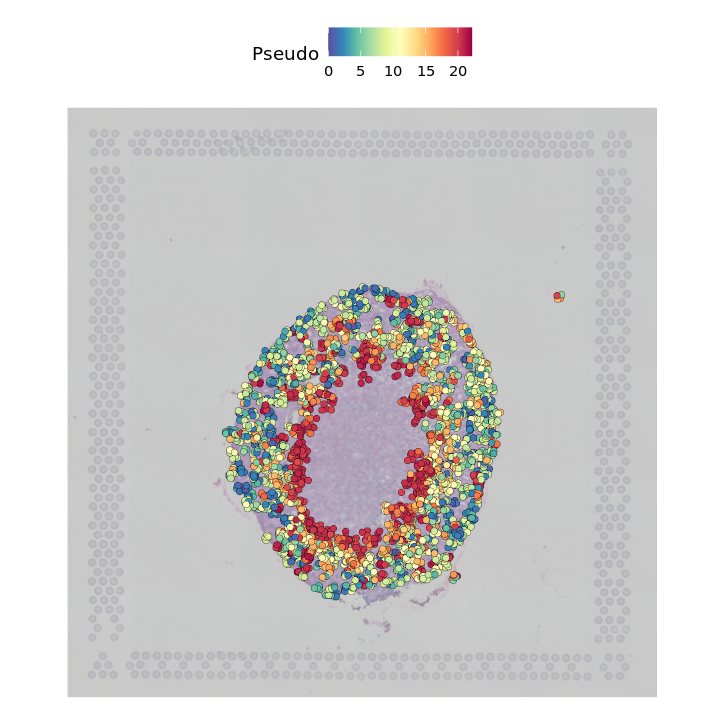

In [530]:
options(repr.plot.width = 6, repr.plot.height = 6)
SpatialFeaturePlot(cell2spatial.sub, features = 'Pseudo', image.alpha = 0.5, crop = FALSE, pt.size.factor = 1.2) + scale_fill_gradientn(colours=SpatialColors(n=100))
ggsave(file.path(out.figs.dir, 'proxtub.pseudo.pdf'), width = 6, height = 6)

- DistTub

In [518]:
meta.data <- pData(disttub.cds@phenoData)
head(meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,nGene,nUMI,replicate,percent.mito,sex,res.1,Lineages,Ontology_ID,mainCtype,nCount_SCT,nFeature_SCT,Size_Factor,num_genes_expressed,Pseudotime,State
,<fct>,<dbl>,<int>,<int>,<dbl>,<fct>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<fct>
Z1_F_F1_AAACGGGAGGCGACAT,Z1,2754.327,2079,2079,6079,F1,0.03750617,F,12,Nephron epithelium,18,DistTub,2616,2079,1.1339258,2079,2.107045,1
Z1_F_F1_AAAGATGCAGCGAACA,Z1,3108.159,2751,2751,8799,F1,0.03954995,F,12,Nephron epithelium,18,DistTub,3203,2751,1.4414311,2751,1.235413,1
Z1_F_F1_AACACGTCAGGAATCG,Z1,1932.029,1105,1105,3107,F1,0.32764725,F,12,Nephron epithelium,18,DistTub,2509,1105,0.6696782,1105,11.316026,7
Z1_F_F1_AACTCAGCAGCTATTG,Z1,2848.374,2602,2602,9410,F1,0.18427205,F,12,Nephron epithelium,18,DistTub,3102,2602,1.3615651,2602,1.604633,1
Z1_F_F1_AAGGCAGAGTCCTCCT,Z1,2314.135,1770,1770,5933,F1,0.26546435,F,12,Nephron epithelium,19,DistTub,2485,1770,0.9464330,1770,6.435136,1
Z1_F_F1_AAGGTTCCAAACTGCT,Z1,2784.997,2198,2198,6486,F1,0.04579093,F,12,Nephron epithelium,18,DistTub,2737,2197,1.1791974,2198,1.773341,1


In [519]:
ovp.cells <- intersect(cell2spatial$RawName, rownames(meta.data))
cell2spatial.sub <- cell2spatial[, ovp.cells]
#cell2spatial.sub$Pseudo <- meta.data[ovp.cells, 'Pseudotime']

In [520]:
#cell2spatial.sub@images$slice1 <- cell2spatial@images$slice1
cell2spatial.sub$Pseudo <- -(meta.data[ovp.cells, 'Pseudotime'] - max(meta.data[ovp.cells, 'Pseudotime']))

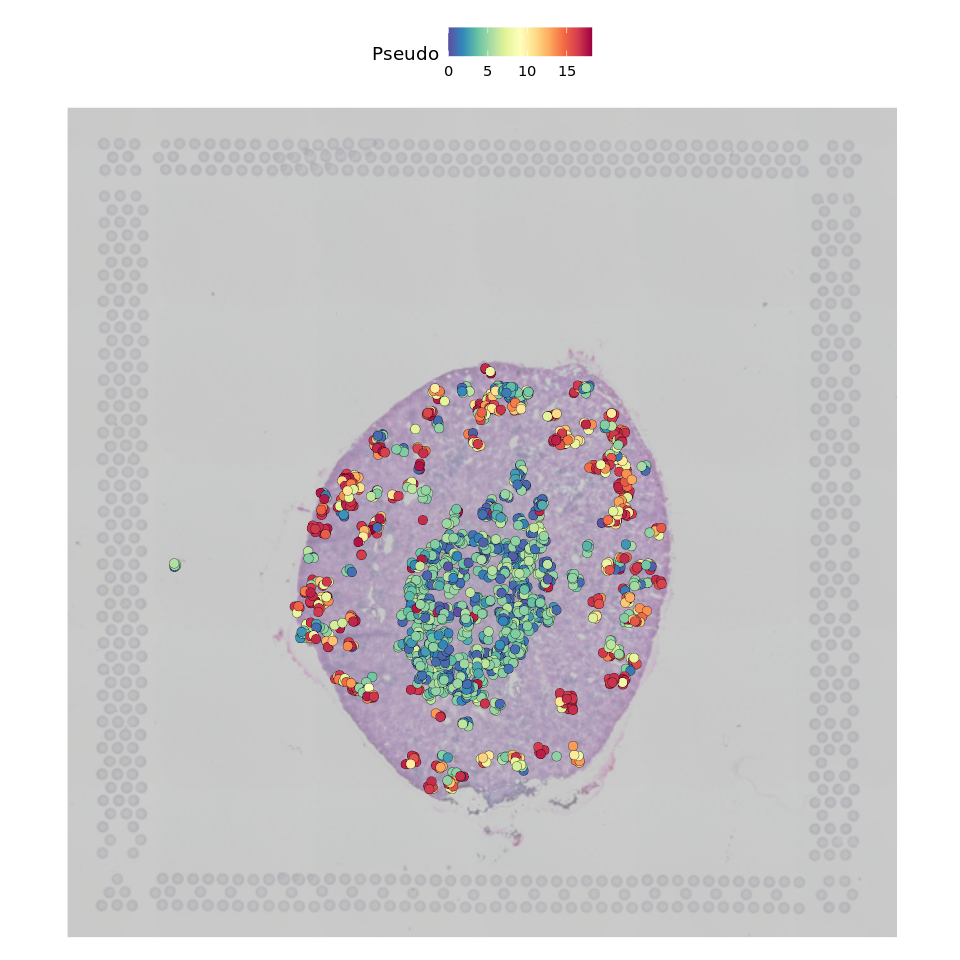

In [521]:
options(repr.plot.width = 8, repr.plot.height = 8)
SpatialFeaturePlot(cell2spatial.sub, features = 'Pseudo', crop = FALSE, pt.size.factor = 1.2, image.alpha = 0.5)
ggsave(file.path(out.figs.dir, 'disttub.pseudo.pdf'), width = 6, height = 6)

### Cell type co-exist analysis

In [538]:
co.index <- coExistIndex(cell2spatial)

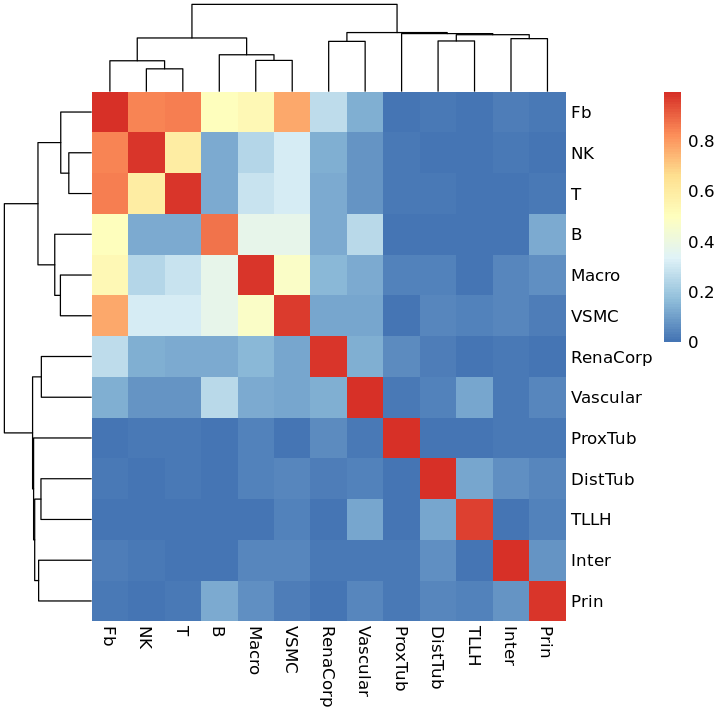

In [565]:
pheatmap::pheatmap(co.index, border_color = NA)
pheatmap::pheatmap(co.index, border_color = NA, width = 6, height = 6, filename = file.path(out.figs.dir, 'coexist.celltypes.pdf'))

In [577]:
openxlsx::write.xlsx(data.frame(co.index), file = file.path(out.data.dir, 'coindex.xlsx'), rowNames = T)

In [543]:
brain.st

An object of class Seurat 
49382 features across 1438 samples within 2 assays 
Active assay: SCT (17097 features, 3000 variable features)
 1 other assay present: Spatial
 2 dimensional reductions calculated: pca, umap
 1 image present: slice1

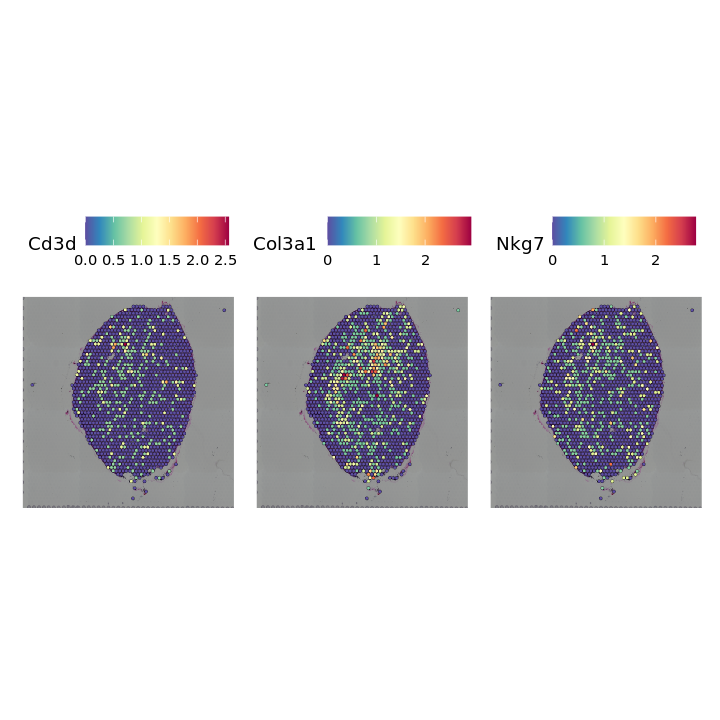

In [566]:
SpatialFeaturePlot(brain.st, features = c('Cd3d', 'Col3a1', 'Nkg7'))
ggsave(file.path(out.figs.dir, 'mouse.st.features.pdf'), width = 8, height = 5)

In [455]:
saveRDS(co.index, file = file.path(out.data.dir, 'co.index.RDS'))